# 선형회귀 실습- 보스턴 주택 가격 예측

## 1. 라이브러리 임포트(import)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 학습셋과 검증셋의 분리
from sklearn.model_selection import train_test_split

## 2. 데이타셋 로드

In [3]:
bostonDF=pd.read_csv('boston.csv')

In [4]:
bostonDF

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


[Features]
* CRIM: 지역별 범죄 발생률  
* ZN: 25,000평방피트를 초과하는 거주 지역의 비율
* INDUS: 비상업 지역 넓이 비율
* CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
* NOX: 일산화질소 농도
* RM: 거주할 수 있는 방 개수
* AGE: 1940년 이전에 건축된 소유자 거주 주택의 비율
* DIS: 5개 주요 고용센터까지의 가중 거리
* RAD: 고속도로 접근 용이도
* TAX: 10,000달러당 재산세율
* PTRATIO: 지역의 교사와 학생 수 비율 (Pupil-Teacher)
* B: 지역의 흑인 거주 비율
* LSTAT: 하위 계층의 비율

[Target]
* PRICE: 보스턴 주택 가격

 ## 3. 학습과 검증 데이터 셋 분리

In [5]:
# PRICE 열만 삭제하여 feature 생성
X_features=bostonDF.drop(["PRICE"], axis=1)
X_features

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [6]:
# PRICE 열만 추출하여 target 생성
y_target=bostonDF['PRICE']

In [7]:
X_train , X_val , y_train , y_val = train_test_split(X_features,y_target, test_size=0.3)

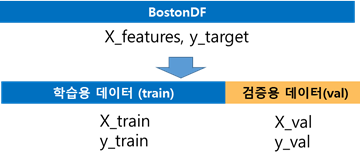

In [8]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
308,0.49298,0.0,9.90,0.0,0.5440,6.635,82.5,3.3175,4.0,304.0,18.4,396.90,4.54
98,0.08187,0.0,2.89,0.0,0.4450,7.820,36.9,3.4952,2.0,276.0,18.0,393.53,3.57
154,1.41385,0.0,19.58,1.0,0.8710,6.129,96.0,1.7494,5.0,403.0,14.7,321.02,15.12
239,0.09252,30.0,4.93,0.0,0.4280,6.606,42.2,6.1899,6.0,300.0,16.6,383.78,7.37
107,0.13117,0.0,8.56,0.0,0.5200,6.127,85.2,2.1224,5.0,384.0,20.9,387.69,14.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,0.38214,0.0,6.20,0.0,0.5040,8.040,86.5,3.2157,8.0,307.0,17.4,387.38,3.13
312,0.26169,0.0,9.90,0.0,0.5440,6.023,90.4,2.8340,4.0,304.0,18.4,396.30,11.72
72,0.09164,0.0,10.81,0.0,0.4130,6.065,7.8,5.2873,4.0,305.0,19.2,390.91,5.52
203,0.03510,95.0,2.68,0.0,0.4161,7.853,33.2,5.1180,4.0,224.0,14.7,392.78,3.81


In [9]:
y_train

308    22.8
98     43.8
154    17.0
239    23.3
107    20.4
       ... 
226    37.6
312    19.4
72     22.8
203    48.5
360    25.0
Name: PRICE, Length: 354, dtype: float64

In [10]:
X_val

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
377,9.82349,0.0,18.10,0.0,0.671,6.794,98.8,1.3580,24.0,666.0,20.2,396.90,21.24
15,0.62739,0.0,8.14,0.0,0.538,5.834,56.5,4.4986,4.0,307.0,21.0,395.62,8.47
14,0.63796,0.0,8.14,0.0,0.538,6.096,84.5,4.4619,4.0,307.0,21.0,380.02,10.26
283,0.01501,90.0,1.21,1.0,0.401,7.923,24.8,5.8850,1.0,198.0,13.6,395.52,3.16
289,0.04297,52.5,5.32,0.0,0.405,6.565,22.9,7.3172,6.0,293.0,16.6,371.72,9.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,16.81180,0.0,18.10,0.0,0.700,5.277,98.1,1.4261,24.0,666.0,20.2,396.90,30.81
462,6.65492,0.0,18.10,0.0,0.713,6.317,83.0,2.7344,24.0,666.0,20.2,396.90,13.99
389,8.15174,0.0,18.10,0.0,0.700,5.390,98.9,1.7281,24.0,666.0,20.2,396.90,20.85
351,0.07950,60.0,1.69,0.0,0.411,6.579,35.9,10.7103,4.0,411.0,18.3,370.78,5.49


In [11]:
y_val

377    13.3
15     19.9
14     18.2
283    50.0
289    24.8
       ... 
385     7.2
462    19.5
389    11.5
351    24.1
93     25.0
Name: PRICE, Length: 152, dtype: float64

## 4. 선형회귀분석

### 4.1) 알고리즘 import

In [12]:
from sklearn.linear_model import LinearRegression 

### 4.2) Estimator 설정

In [13]:
linear_reg = LinearRegression()   

- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- parameters, attributes, method 확인!

In [14]:
# 절편 확인 (학습 전)
#linear_reg.intercept_ #학습전이라 확인이 안됨(에러남)

In [15]:
# 회귀계수 확인 (학습 전)
#linear_reg.coef_  #학습전이라 확인이 안됨(에러남)

### 4.3) 학습

In [16]:
linear_reg.fit(X_train ,y_train )

LinearRegression()

In [17]:
# 절편 확인 (학습후)
linear_reg.intercept_

34.51192692291022

In [18]:
# 회귀계수 확인 (학습후)
linear_reg.coef_

array([-1.30051344e-01,  5.23938620e-02,  4.08339960e-02,  4.46790661e-01,
       -1.62035807e+01,  3.95436585e+00, -1.74560830e-03, -1.51258602e+00,
        3.29200140e-01, -1.22552867e-02, -1.04271532e+00,  1.43194401e-02,
       -5.27259531e-01])

In [19]:
X_features.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [20]:
#회귀계수값을 DataFrame으로 작성 - data만 설정
coeff = pd.DataFrame(data = np.round(linear_reg.coef_,1))
coeff

,0
0,-0.1
1,0.1
2,0.0
3,0.4
4,-16.2
5,4.0
6,-0.0
7,-1.5
8,0.3
9,-0.0


In [21]:
#회귀계수값을 DataFrame으로 작성
coeff = pd.DataFrame(data = np.round(linear_reg.coef_,1), 
                    index= X_features.columns,
                    columns = ['coef_'])
coeff

,coef_
CRIM,-0.1
ZN,0.1
INDUS,0.0
CHAS,0.4
NOX,-16.2
RM,4.0
AGE,-0.0
DIS,-1.5
RAD,0.3
TAX,-0.0


In [22]:
# coeff를 큰 값 순으로 정렬
coeff.sort_values(by=['coef_'], ascending=False)

,coef_
RM,4.0
CHAS,0.4
RAD,0.3
ZN,0.1
INDUS,0.0
AGE,-0.0
TAX,-0.0
B,0.0
CRIM,-0.1
LSTAT,-0.5


### 4.4) 예측

In [23]:
y_preds = linear_reg.predict(X_val)

In [24]:
# 예측값 확인 
y_preds

array([20.90059153, 19.06839489, 18.94252115, 43.32877703, 27.14825767,
       11.74404773, 17.46834174, 22.46809161, 23.96066212, 16.79920193,
       29.95374996,  8.13880028, 21.25415888, 20.54964448, 16.90852124,
       29.79087687, 19.57471057, 17.05826786, 24.17503437, 30.11515498,
       13.14048036, 19.8608689 , 26.00960009, 20.33073331, 21.47522689,
       15.60953931, 29.26504993, 18.06459066, 32.05487073, 14.63334553,
       24.61918688, 20.27972107, 31.25412616, 17.81358912, 33.80582358,
       12.13442641, 23.11033585, 16.23442676,  6.63413963, 18.12330207,
       32.93295317, 17.10088258, 21.97508413, 25.32825652, 15.54923751,
       16.51918903, 19.83919761, 21.42378823, 21.85289991, 28.97543858,
       35.11553813, 27.84498683, 19.24428359, 20.45722272, 19.95600594,
       24.42740894, 35.73729295, 13.94815986, 16.58895021, 27.63358796,
       24.60317703,  9.61364884,  6.40013543, 20.78495466, 30.84892325,
       27.48728905, 30.33638382, 11.46795053, 24.15549884, 32.41

In [25]:
# 실제값 확인 
y_val

355    20.6
315    16.2
233    48.3
444    10.8
279    35.1
       ... 
118    20.4
47     16.6
419     8.4
236    25.1
431    14.1
Name: PRICE, Length: 152, dtype: float64

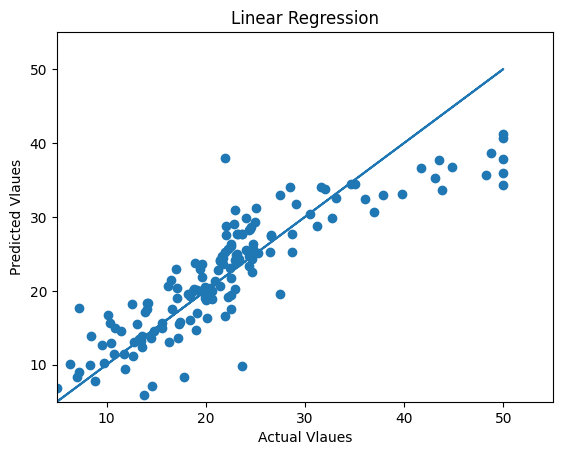

In [26]:
# 예측 결과 가시화
plt.title('Linear Regression')
plt.xlabel('Actual Vlaues')
plt.ylabel('Predicted Vlaues')
plt.plot(y_val, y_val)       #실제값
plt.scatter(y_val, y_preds)   #예측값
plt.axis([5,55,5,55])
plt.show()

### 4.5) 평가

- 평가지표: MSE, RMSE, R-Square

In [27]:
# 평가지표(함수) import
from sklearn.metrics import mean_squared_error, r2_score      # MSE, R-Sqaure

In [28]:
# mse
mse=mean_squared_error(y_val, y_preds)  #실제깂, 예측값
print(mse)

23.80945520091551


In [29]:
# rmse
rmse=np.sqrt(mse)  #제곱근 처리
print(rmse)

4.879493334447288


In [30]:
# r-square
r2_score=r2_score(y_val, y_preds)  #실제깂, 예측값
print(r2_score)

0.753113021992313
